<a href="https://colab.research.google.com/github/meenukashwer22/meenukashwer22/blob/main/Exploratory%20Weather%20Data%20Analysis%20%26%20Visualization%20(Python).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

## Google Colab is available in VS Code!
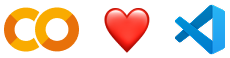

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

# New Section

['Date', 'Max_TemperatureC', 'Mean_TemperatureC', 'Min_TemperatureC']
       Date  Max_TemperatureC  Mean_TemperatureC  Min_TemperatureC
0  1/1/1948                10                8.0               7.0
1  1/2/1948                 6                4.0               3.0
2  1/3/1948                 7                4.0               2.0
3  1/4/1948                 7                4.0               2.0
4  1/5/1948                 7                3.0               0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24381 entries, 0 to 24380
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               24381 non-null  object 
 1   Max_TemperatureC   24381 non-null  int64  
 2   Mean_TemperatureC  24376 non-null  float64
 3   Min_TemperatureC   24380 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 762.0+ KB
None


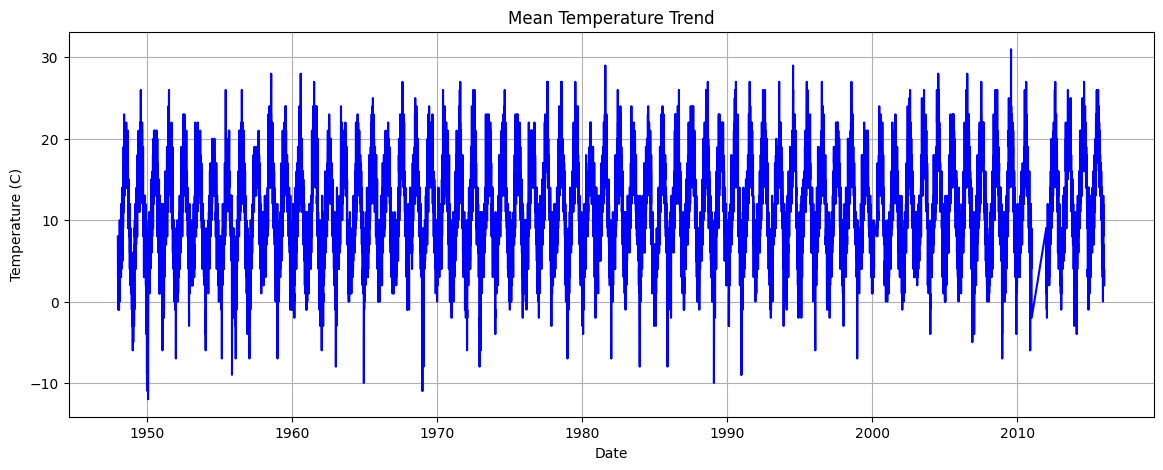

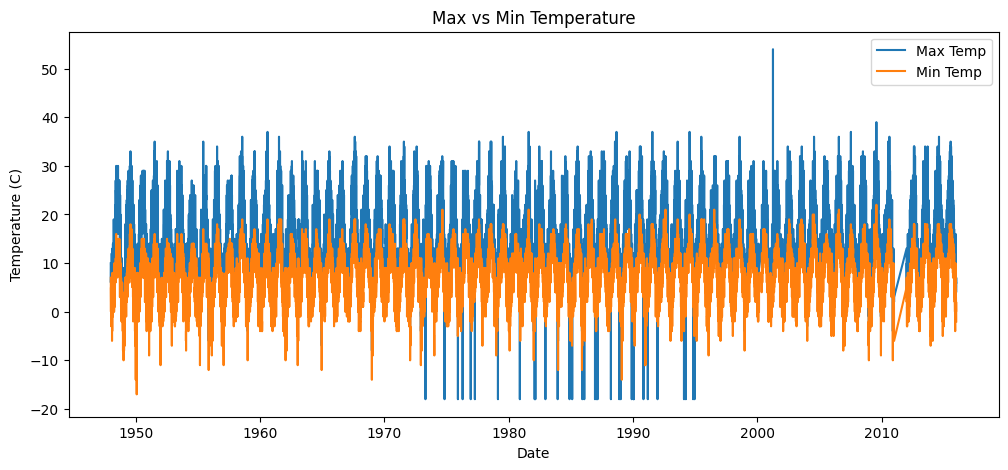

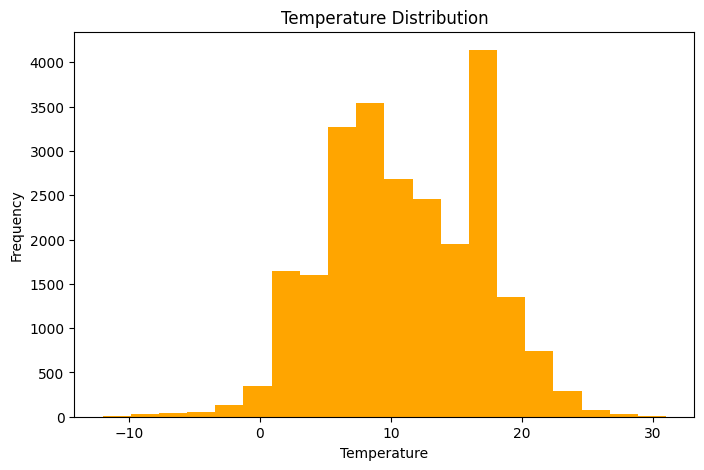

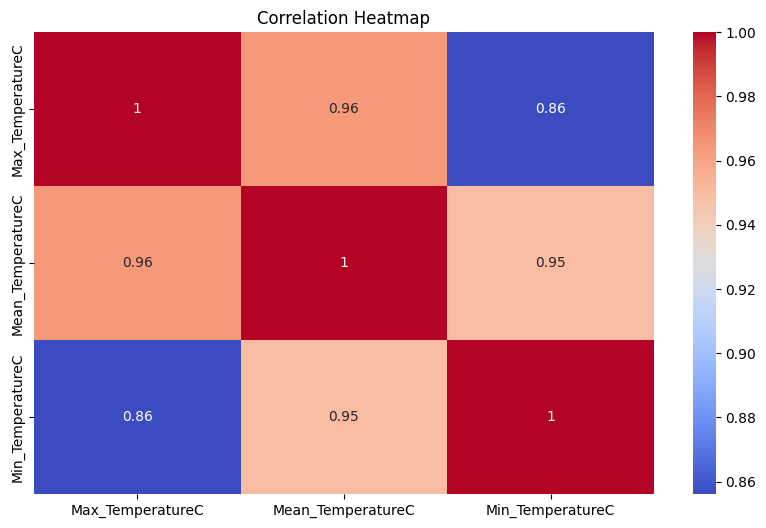

In [18]:
# =====================================
# IMPORT LIBRARIES
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# LOAD DATASET
# =====================================

file_path = "/content/MICHIGAN BLUF, CA US (USC00045586.csv).csv"

df = pd.read_csv(file_path)

# =====================================
# CLEAN COLUMN NAMES
# =====================================

df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("/", "_")

# =====================================
# CHECK COLUMN NAMES
# =====================================

print(df.columns.tolist())

# =====================================
# DISPLAY DATA
# =====================================

print(df.head())

# =====================================
# DATASET INFO
# =====================================

print(df.info())

# =====================================
# REMOVE MISSING VALUES
# =====================================

df = df.dropna()

# =====================================
# CONVERT DATE COLUMN
# =====================================

df['Date'] = pd.to_datetime(df['Date'])

# =====================================
# TEMPERATURE TREND GRAPH
# =====================================

plt.figure(figsize=(14,5))

plt.plot(df['Date'], df['Mean_TemperatureC'], color='blue')

plt.title('Mean Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.grid(True)

plt.show()

# =====================================
# MAX VS MIN TEMPERATURE
# =====================================

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Max_TemperatureC'], label='Max Temp')
plt.plot(df['Date'], df['Min_TemperatureC'], label='Min Temp')

plt.title('Max vs Min Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.legend()

plt.show()

# =====================================
# TEMPERATURE DISTRIBUTION
# =====================================

plt.figure(figsize=(8,5))

plt.hist(df['Mean_TemperatureC'], bins=20, color='orange')

plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()

# =====================================
# CORRELATION HEATMAP
# =====================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


### Exploring Seasonal Variations

/tmp/ipykernel_59110/4207502404.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Mean_TemperatureC', data=monthly_avg_temp, palette='viridis')


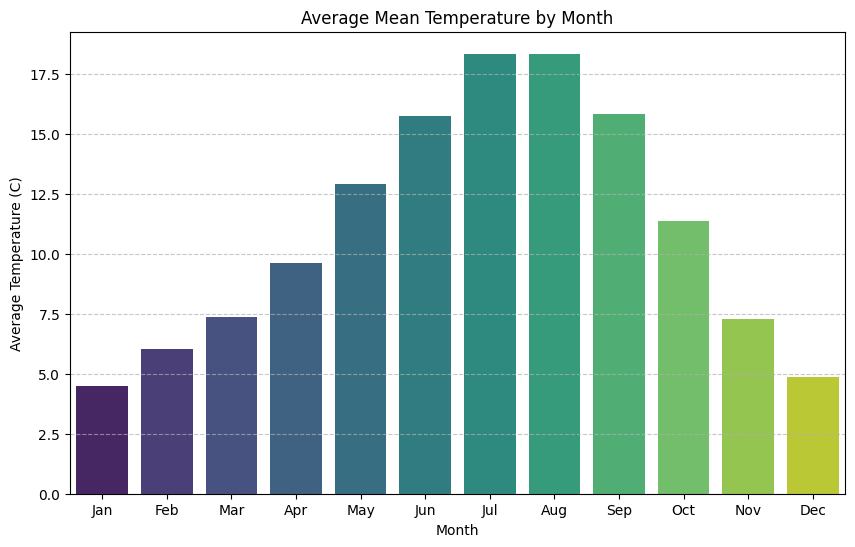

In [20]:
# Extract month and year for seasonal analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Calculate monthly average temperature
monthly_avg_temp = df.groupby('Month')['Mean_TemperatureC'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Mean_TemperatureC', data=monthly_avg_temp, hue='Month', palette='viridis', legend=False)
plt.title('Average Mean Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Average Temperature (C)')
plt.xticks(ticks=range(0,12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

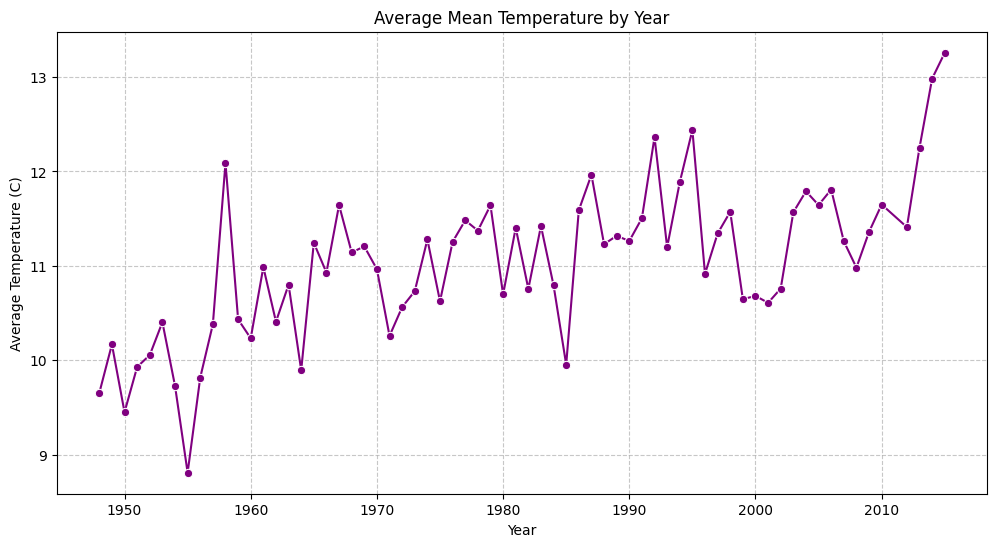

In [21]:
# Calculate yearly average temperature
yearly_avg_temp = df.groupby('Year')['Mean_TemperatureC'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Mean_TemperatureC', data=yearly_avg_temp, marker='o', color='purple')
plt.title('Average Mean Temperature by Year')
plt.xlabel('Year')
plt.ylabel('Average Temperature (C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [23]:
print(df.columns.tolist())

['Date', 'Max_TemperatureC', 'Mean_TemperatureC', 'Min_TemperatureC', 'Month', 'Year']
